In [1]:
import pandas as pd
df=pd.read_csv(r"C:\Users\hi\Downloads\Resume\Resume.csv")
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [3]:
job_description = """
Machine Learning Intern

Required Skills:
Python
Machine Learning
Pandas
NumPy
SQL
Scikit-Learn
Data Analysis
"""

In [5]:
import re

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    text = re.sub(r'\s+', ' ', text)

    return text

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents = df["Resume_str"].tolist()

documents.append(job_description)

vectorizer = TfidfVectorizer(stop_words='english')

tfidf_matrix = vectorizer.fit_transform(documents)

In [13]:
print(df.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')


In [15]:
from sklearn.metrics.pairwise import cosine_similarity

job_vector = tfidf_matrix[-1]

resume_vectors = tfidf_matrix[:-1]

scores = cosine_similarity(
    resume_vectors,
    job_vector
)

df["Match Score"] = scores * 100

In [17]:
ranked = df.sort_values(
    by="Match Score",
    ascending=False
)

print(
    ranked[
        ["Category", "Match Score"]
    ].head(10)
)

         Category  Match Score
1339   AUTOMOBILE    19.464820
926   AGRICULTURE    19.204698
2153      BANKING    17.793516
1762  ENGINEERING    17.078133
1218   CONSULTANT    12.675356
2291         ARTS    12.558533
1142   CONSULTANT    11.238359
1348   AUTOMOBILE    10.744862
194      DESIGNER    10.557331
374       TEACHER     9.712248


In [19]:
skills = [
    "python",
    "sql",
    "pandas",
    "numpy",
    "machine learning",
    "scikit-learn",
    "tensorflow",
    "deep learning",
    "power bi",
    "excel"
]

In [21]:
def extract_skills(text):

    text = text.lower()

    found = []

    for skill in skills:
        if skill in text:
            found.append(skill)

    return found

In [27]:
job_skills = extract_skills(job_description)

candidate_skills = extract_skills(
    ranked.iloc[0]["Resume_str"]
)

missing = list(
    set(job_skills) -
    set(candidate_skills)
)

print("Missing Skills:", missing)

Missing Skills: ['machine learning', 'scikit-learn']


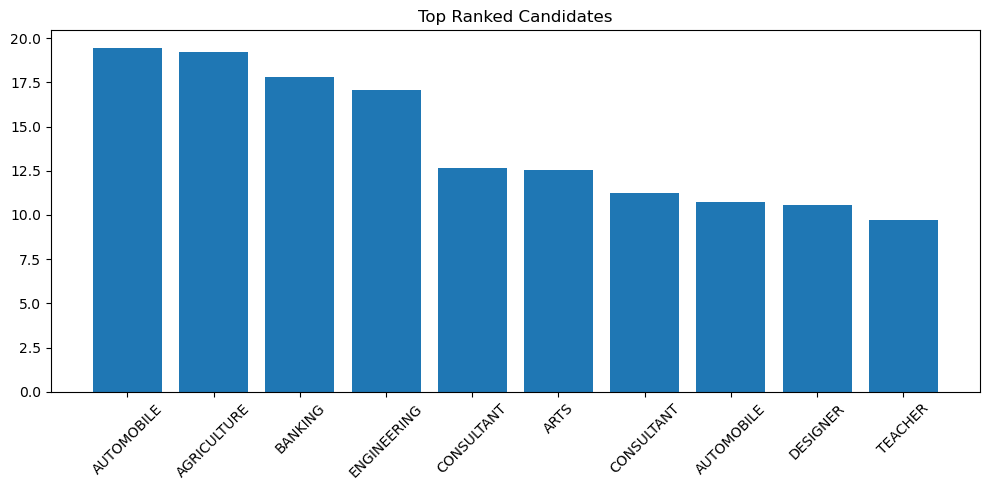

In [29]:
import matplotlib.pyplot as plt

top10 = ranked.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    range(len(top10)),
    top10["Match Score"]
)

plt.xticks(
    range(len(top10)),
    top10["Category"],
    rotation=45
)

plt.title("Top Ranked Candidates")

plt.tight_layout()

plt.show()